# Crude Preheat Train in Front of the CDU

A crude unit's fuel bill is set as much by its preheat train as by its column.
The crude leaves the tank at ambient temperature and reaches the furnace at
250 C or so. Most of that heat is recovered from the column's own products and
pumparounds, and the furnace supplies the rest. Fouling of the exchangers
shows up as a cooler furnace inlet and a larger fired duty.

The train and the column are coupled both ways. The hot streams are the
column's products and pumparounds, so their rates and temperatures come from
the column. The column's feed and its pumparound return temperatures come
from the train. `PreheatedCrudeUnit` solves the two together:

1. **tank**: crude at 27 C with 0.2 vol % water;
2. **cold train**: three exchangers heat it against the kerosene, the
   residue's cold end and the top pumparound;
3. **desalter**: wash water is mixed in and brine leaves;
4. **hot train**: diesel and AGO exchangers;
5. **preflash drum**: the light ends and some naphtha flash off at 3 bar and
   go to the column above the flash zone;
6. three more exchangers (bottom pumparound, then the residue twice);
7. **furnace and column**: the 30-stage atmospheric column of
   [the refinery docs](../docs/unit-operations-refinery.md).

Every number below is differentiable. The derivatives are implicit-function
derivatives through the coupled solve, so asking how the fired duty depends on
one exchanger's fouling resistance costs one gradient, not a re-solve.

**The fouling constants are illustrative.** The Ebert-Panchal model's form is
the published one. Its constants are not fitted to any crude: they were
chosen to give the right order of magnitude. The cleaning ranking at the end
shows the method, and its numbers would come from your own monitoring data.

In [1]:
import time

import jax
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import difflow_refinery as dr
from difflow_refinery import column as cc
from difflow_refinery.preheat.fouling import EbertPanchal, fouling_rates

C = 273.15

## The crude and the column

These are the assay and the 30-stage column from the refinery documentation:
three side strippers, two pumparounds, and a 5 vol % overflash closing the
furnace. The pumparounds are the one change. They are specified by
circulation rate and return temperature, not by duty. The train cools them,
so the return temperature becomes the train's answer, and the spec value only
starts the loop.

In [2]:
PCT = [0, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 95, 100]
T_C = [-10, 60, 95, 150, 205, 260, 315, 370, 430, 500, 600, 680, 850]
assay = dr.Assay(PCT, [t + C for t in T_C], sg=0.86,
                 light_ends={"propane": 0.5, "n_butane": 1.0, "n_pentane": 1.5})

BPD = 95_000.0
crude = dr.characterize(assay)
thermo = dr.ColumnThermo.from_characterization(crude)
kg_s = BPD * cc.BARREL / 86400.0 * float(crude.bulk_sg) * 999.016
s = crude.stream(kg_s, T=300.0, P=1e5, basis="mass")
Vf = float(thermo.std_volume(jnp.stack([jnp.asarray(s[f"F_{n}"]) for n in thermo.names])))

yields = {"naphtha": 0.20, "kero": 0.11, "diesel": 0.17, "ago": 0.05}
column = cc.CrudeColumnParams(
    n_stages=30, feed_stage=27, P_top=1.5e5, P_bottom=1.9e5, P_condenser=1.3e5,
    bottom_steam=150.0, steam_T=C + 260.0,
    side_products=(cc.SideProduct("kero", 9, 4, steam=40.0), cc.SideProduct("diesel", 16, 4, steam=40.0),
                   cc.SideProduct("ago", 22, 3, steam=20.0)),
    pumparounds=(cc.Pumparound("pa1", 12, 10), cc.Pumparound("pa2", 19, 17)),
    specs=tuple(cc.product_rate(n, f * Vf) for n, f in yields.items())
    + (cc.pumparound_rate("pa1", 0.5 * Vf), cc.pumparound_return_temperature("pa1", 400.0),
       cc.pumparound_rate("pa2", 0.6 * Vf), cc.pumparound_return_temperature("pa2", 470.0),
       cc.overflash(0.05)),
    furnace=cc.Furnace(efficiency=0.85),
)

## The train

There are eight exchangers. Each is listed with its clean U and its area, and
each hot stream lists its exchangers hottest first. The residue passes through
E8, then E7, then E2 at the cold end. The crude path gives the order in which
the crude meets everything. This layout is a textbook one, not that of any
real unit.

Each exchanger's UA is `A / (1/U + R_f)`, and its duty satisfies the LMTD
equation (with an F-factor when it has shell passes). The crude side is a
three-phase flash: hydrocarbon liquid, vapour, and free water.

In [3]:
def train(Rf=None):
    Rf = Rf or {}
    areas = {"E1": 300.0, "E2": 1200.0, "E3": 1500.0, "E4": 600.0,
             "E5": 300.0, "E6": 1500.0, "E7": 1500.0, "E8": 1200.0}
    return dr.PreheatTrainParams(
        exchangers=tuple(dr.PreheatExchanger(n, 350.0, A, Rf=Rf.get(n, 0.0)) for n, A in areas.items()),
        hot_streams=(dr.HotStream("residue", ("E8", "E7", "E2")), dr.HotStream("pa2", ("E6",)),
                     dr.HotStream("ago", ("E5",)), dr.HotStream("diesel", ("E4",)),
                     dr.HotStream("pa1", ("E3",)), dr.HotStream("kero", ("E1",))),
        crude_path=("E1", "E2", "E3", "desalter", "E4", "E5", "preflash", "E6", "E7", "E8"),
        desalter=dr.DesalterParams(),            # 5 vol % wash water, 95 % salt removal
        drum=dr.PreflashDrumParams(P=3.0e5),     # adiabatic, 3 bar
    )

unit = dr.PreheatedCrudeUnit(assay, column, train())
t0 = time.time()
clean = unit.solve(BPD, T_tank=300.0)
print(f"solved in {time.time() - t0:.0f} s (most of it compiling), "
      f"{int(clean.iterations)} outer iterations, converged={bool(clean.converged)}")
print(clean.table())

solved in 41 s (most of it compiling), 4 outer iterations, converged=True
exchanger     Q MW  crude in     out   hot in     out  UA kW/K
E1            3.25      26.9    38.7    131.5    32.4    105.0
E2           23.70      38.7   115.3    208.8    69.5    420.0
E3            9.89     115.3   143.5    179.8   123.5    525.0
E4            3.24     140.8   149.7    195.9   143.6    210.0
E5            2.19     149.7   155.6    261.1   150.4    105.0
E6           19.64     150.4   203.4    256.9   175.4    525.0
E7            5.79     203.4   218.0    237.9   208.8    525.0
E8           13.96     218.0   251.2    302.9   237.9    420.0
desalter 140.8 C
preflash 150.4 C, 3.00 bar, 8.9 mol% flashed
recovered 81.7 MW; furnace inlet 251.2 C, fired 46.5 MW


The solve starts from the unit's default guess. Its outer Newton iteration
works on the pumparound return temperatures, the drum temperature and the
furnace inlet temperature, and it converges in a few iterations. Each
iteration solves the train and the column on their own.

The overall balances run from tank to products. The inputs are the crude, the
wash water, the steam and the furnace's absorbed duty. The outputs are the
brine, the products at the temperatures at which they leave the train, and
the condenser duty.

In [4]:
for k, (i, o, rel) in unit.balances(clean).items():
    print(f"{k:12s} relative imbalance {float(rel):+.1e}")

hydrocarbon  relative imbalance -9.7e-13
water        relative imbalance +6.0e-16
energy       relative imbalance -1.5e-12


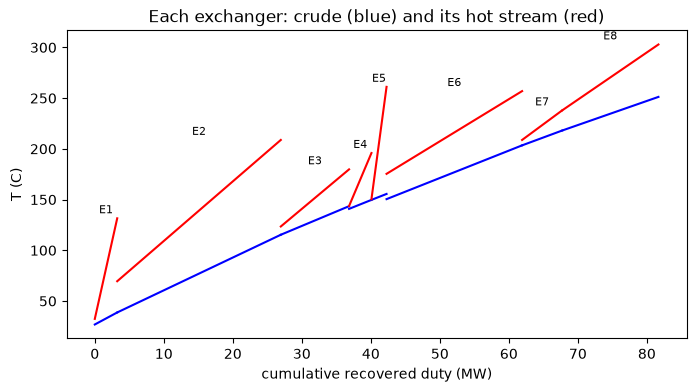

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
x = 0.0
for name in clean.train.exchangers:
    e = clean.train.exchangers[name]
    Q = float(e["Q"]) / 1e6
    ax.plot([x, x + Q], [float(e["T_cold_in"]) - C, float(e["T_cold_out"]) - C], "b-")
    ax.plot([x, x + Q], [float(e["T_hot_out"]) - C, float(e["T_hot_in"]) - C], "r-")
    ax.text(x + Q / 2, float(e["T_hot_in"]) - C + 5, name, ha="center", fontsize=8)
    x += Q
ax.set_xlabel("cumulative recovered duty (MW)")
ax.set_ylabel("T (C)")
ax.set_title("Each exchanger: crude (blue) and its hot stream (red)")
plt.show()

The drops in the blue line between exchangers are the desalter, where cold
wash water is mixed in, and the preflash drum, which cools the crude as some
of it flashes. The drum's vapour bypasses the furnace and enters the column on
the stage above the flash zone.

In [6]:
d, ds = clean.train.drum, clean.train.desalter
print(f"desalter at {float(ds['T']) - C:.1f} C, margins to its 120-150 C window: "
      f"{float(ds['margin_low']):+.1f} / {float(ds['margin_high']):+.1f} K")
print(f"preflash drum at {float(d['T']) - C:.1f} C, {float(d['P']) / 1e5:.1f} bar: "
      f"{100 * float(d['vapor_fraction']):.1f} mol % of the hydrocarbons flashed")

desalter at 140.8 C, margins to its 120-150 C window: +20.8 / +9.2 K
preflash drum at 150.4 C, 3.0 bar: 8.9 mol % of the hydrocarbons flashed


## Fouling

The Ebert-Panchal threshold model gives each exchanger a fouling rate. That
rate is deposition, which is Arrhenius in the crude-side film temperature,
less removal, which goes with wall shear. Below the threshold the rate is
zero. The crude side's Reynolds number, Prandtl number and wall shear are
inputs here (one value for every exchanger), because the train carries no
geometry beyond the area. **The constants are the illustrative defaults.**

In [7]:
YEAR = 365.0 * 86400.0
rates = fouling_rates(clean.train, unit.train_params, EbertPanchal())
for n, r in rates.items():
    print(f"{n}: {float(r) * YEAR:.2e} m2K/W per year")

E1: 0.00e+00 m2K/W per year
E2: 0.00e+00 m2K/W per year
E3: 0.00e+00 m2K/W per year
E4: 1.15e-05 m2K/W per year
E5: 2.28e-05 m2K/W per year
E6: 8.25e-05 m2K/W per year
E7: 2.02e-04 m2K/W per year
E8: 4.10e-04 m2K/W per year


The pattern is the useful part. The cold end (E1-E3) is below the threshold
and does not foul, and the rate rises steeply towards the hot end. Take
`R_f(t) = rate * t`, a linear fouling history, and follow the fired duty over
three years. At each point we also take the derivative `d(fired)/dt`. It is a
forward-mode JVP through the coupled solve, and its tangent line is drawn
through that point.

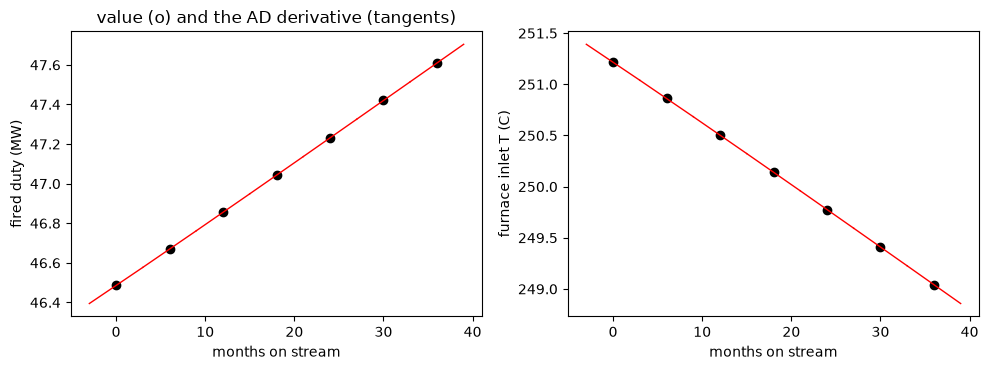

after 18 months: fired 47.04 MW (clean 46.49), rising at 0.38 MW per year


In [8]:
rate_vec = jnp.asarray([float(rates[e.name]) for e in unit.train_params.exchangers])
base = unit.train_params

def fired_after(months):
    Rf = rate_vec * months * YEAR / 12.0
    t = base.update(exchangers=tuple(e.update(Rf=Rf[i]) for i, e in enumerate(base.exchangers)))
    r = unit.solve(BPD, 300.0, train=t)
    return jnp.stack([r.fired_duty / 1e6, r.furnace_inlet_T - C])

months = [0.0, 6.0, 12.0, 18.0, 24.0, 30.0, 36.0]
vals, slopes = [], []
for m in months:
    v, dv = jax.jvp(fired_after, (jnp.asarray(m),), (jnp.asarray(1.0),))
    vals.append(np.asarray(v)); slopes.append(np.asarray(dv))
vals, slopes = np.array(vals), np.array(slopes)

fig, axs = plt.subplots(1, 2, figsize=(10, 3.8))
for k, (ax, lab) in enumerate(zip(axs, ["fired duty (MW)", "furnace inlet T (C)"])):
    ax.plot(months, vals[:, k], "ko")
    for m, v, s in zip(months, vals[:, k], slopes[:, k]):
        ax.plot([m - 3, m + 3], [v - 3 * s, v + 3 * s], "r-", lw=1)
    ax.set_xlabel("months on stream"); ax.set_ylabel(lab)
axs[0].set_title("value (o) and the AD derivative (tangents)")
plt.tight_layout(); plt.show()
print(f"after 18 months: fired {vals[3, 0]:.2f} MW (clean {vals[0, 0]:.2f}), "
      f"rising at {slopes[3, 0] * 12:.2f} MW per year")

A finite difference confirms the derivative at 18 months. The step is 0.01
month, and the difference is central:

In [9]:
h = 0.01
fd = (fired_after(18.0 + h) - fired_after(18.0 - h)) / (2 * h)
print("AD:", slopes[3], " FD:", np.asarray(fd), " relative difference:",
      np.abs((slopes[3] - np.asarray(fd)) / np.asarray(fd)))

AD: [ 0.0313165  -0.06057988]  FD: [ 0.0313165  -0.06057988]  relative difference: [7.97820255e-10 1.11563638e-09]


## Which exchanger to clean

At 18 months, `fouling_sensitivity` gives `d(fired duty)/d(R_f)` for all
eight exchangers from **one** reverse-mode gradient. Multiplied by each
exchanger's `R_f`, it is a linear estimate of what cleaning that exchanger
would save. `cleaning_ranking` reports that estimate next to the exact saving,
which it gets by re-solving with the exchanger clean, and sorts by the exact
saving.

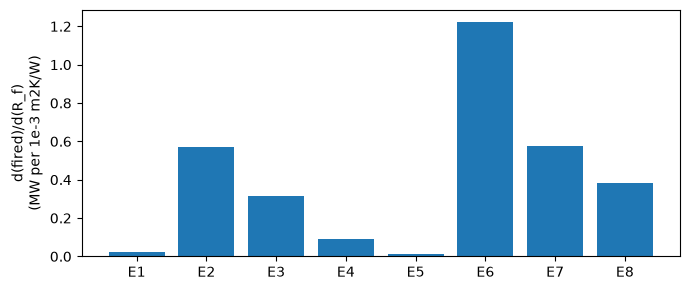

{'E1': 0.022, 'E2': 0.573, 'E3': 0.314, 'E4': 0.091, 'E5': 0.013, 'E6': 1.224, 'E7': 0.577, 'E8': 0.383} MW per 1e-3 m2K/W


exchanger   R_f m2K/W  linear MW   exact MW
E8           6.15e-04      0.236      0.258
E7           3.03e-04      0.175      0.180
E6           1.24e-04      0.151      0.153
E4           1.73e-05      0.002      0.002
E5           3.42e-05      0.000      0.000
E1           0.00e+00      0.000      0.000
E2           0.00e+00      0.000      0.000
E3           0.00e+00      0.000      0.000


In [10]:
Rf18 = {e.name: float(rate_vec[i]) * 1.5 * YEAR for i, e in enumerate(base.exchangers)}
t18 = train(Rf18)
sens = unit.fouling_sensitivity(BPD, 300.0, train=t18)
fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(list(sens), [float(v) / 1e6 / 1e3 for v in sens.values()])
ax.set_ylabel("d(fired)/d(R_f)\n(MW per 1e-3 m2K/W)")
plt.tight_layout(); plt.show()
print({k: round(float(v) / 1e9, 3) for k, v in sens.items()}, "MW per 1e-3 m2K/W")

rows = unit.cleaning_ranking(BPD, 300.0, train=t18)
print(f"{'exchanger':10s} {'R_f m2K/W':>10s} {'linear MW':>10s} {'exact MW':>10s}")
for r in rows:
    print(f"{r['name']:10s} {r['Rf']:10.2e} {r['linear_saving'] / 1e6:10.3f} {r['saving'] / 1e6:10.3f}")

Per unit of `R_f`, the most expensive exchanger to foul is E6, the bottom
pumparound's exchanger, at about 1.2 MW per 1e-3 m2K/W. E2 at the cold end
costs as much as E7 (about 0.57 each), and more than E8 (0.38). So the hot end
tops the ranking only because only the hot end fouls. E8 comes first because
it has twice E7's resistance, not because a unit of fouling there costs more.
That is the point of keeping the two numbers apart: the sensitivity says
where fouling hurts, and the fouling model says where it happens.

The linear estimate and the exact saving agree in order and to within about
10 %. The gap between them is the curvature of `UA = A/(1/U + R_f)`, together
with the train's own response. For a cleaning schedule, the gradient is enough
to rank the exchangers, and the re-solve sizes the saving.

The same unit is available as a flowsheet operation (`CrudeUnitWithPreheat`)
and as a planning block. In `difflow_refinery.planning.cdu_block`, every
exchanger's `R_f`, area and bypass, the tank temperature, the desalter wash
and the drum pressure are levers. The furnace inlet temperature, the recovered
duty and each exchanger's duty and approach are outputs.